<a href="https://colab.research.google.com/github/kursatkara/MAE_5020_Spring_2026/blob/master/04_07_Interpolation_Extrapolation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Interpolation vs Extrapolation: Wind Tunnel Envelope Expansion

In aerospace testing, we often gather data within a safe, controlled **Tested Envelope** (e.g., Wind Tunnel data from Mach 0.0 to 0.4). We fit mathematical models to this data to predict aerodynamic behavior.

*   **Interpolation**: Using the model to predict behavior *within* the bounds of the tested training data (e.g., predicting behavior at Mach 0.2). Models usually perform very reliably here.
*   **Extrapolation**: Using the model to predict behavior *outside* the bounds of the training data (e.g., predicting behavior at Mach 0.7 based only on Mach 0.0-0.4 data).

**The Danger of High-Degree Polynomials:**
While high-degree polynomials can achieve near-zero error on the training data (perfect interpolation), they tend to oscillate wildly outside the training bounds (Runge's Phenomenon). Extrapolating with them is incredibly dangerous, as we will demonstrate.

The code from the textbook [1] was modified and enhanced to highlight this concept.

[1] https://github.com/kursatkara/databook_python/blob/master/CH04/CH04_SEC05_1_CrossValidate.ipynb

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams.update({'font.size': 14})
rcParams['axes.grid'] = True
rcParams['figure.figsize'] = [10, 5]

In [29]:
# Data Setup

n_points = 200
mach_max = 0.8
mach_array = np.linspace(0, mach_max, n_points)

# Split the domain into Training (Tested) and Testing (Extrapolation) Data
# First 100 points: Mach 0.0 to 0.4 (Tested Envelope)
n_train = 100
mach_train = mach_array[:n_train]

# Remaining 100 points: Mach 0.4 to 0.8 (Extrapolation Envelope)
mach_test = mach_array[n_train:]

# The "True" Physical Behavior of the Pitching Moment Coefficient (C_M)
# A complex curve that we will try to model.
C_M_true = np.sin(mach_array * 15) + np.exp(mach_array)

C_M_train = C_M_true[:n_train]
C_M_test  = C_M_true[n_train:]

In [30]:
# We will test polynomial models of varying complexity, from Degree 1 to 30
max_degree = 30

# Arrays to store the Mean Squared Error (MSE) for each polynomial degree
mse_train = np.zeros(max_degree) # Error inside the tested envelope
mse_test  = np.zeros(max_degree) # Error outside the tested envelope (extrapolation)

# Loop through polynomial degrees 1 through 30
for degree in range(1, max_degree + 1):

    # Fit the polynomial ONLY using the training data
    # np.polyfit returns the coefficients [p_n, p_n-1, ..., p_0]
    coefficients = np.polyfit(mach_train, C_M_train, degree)

    # Predict the values for both regions
    C_M_pred_train = np.polyval(coefficients, mach_train)
    C_M_pred_test  = np.polyval(coefficients, mach_test)

    # Calculate Mean Squared Error
    mse_train[degree - 1] = np.mean((C_M_pred_train - C_M_train)**2)
    mse_test[degree - 1]  = np.mean((C_M_pred_test  - C_M_test)**2)

print("Polynomial fitting and error calculation complete.")

Polynomial fitting and error calculation complete.


/tmp/ipykernel_1810/711605169.py:13: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(mach_train, C_M_train, degree)
/tmp/ipykernel_1810/711605169.py:13: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(mach_train, C_M_train, degree)
/tmp/ipykernel_1810/711605169.py:13: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(mach_train, C_M_train, degree)
/tmp/ipykernel_1810/711605169.py:13: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(mach_train, C_M_train, degree)
/tmp/ipykernel_1810/711605169.py:13: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(mach_train, C_M_train, degree)
/tmp/ipykernel_1810/711605169.py:13: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(mach_train, C_M_train, degree)
/tmp/ipykernel_1810/711605169.py:13: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(mach_train, C_M_train, degree)

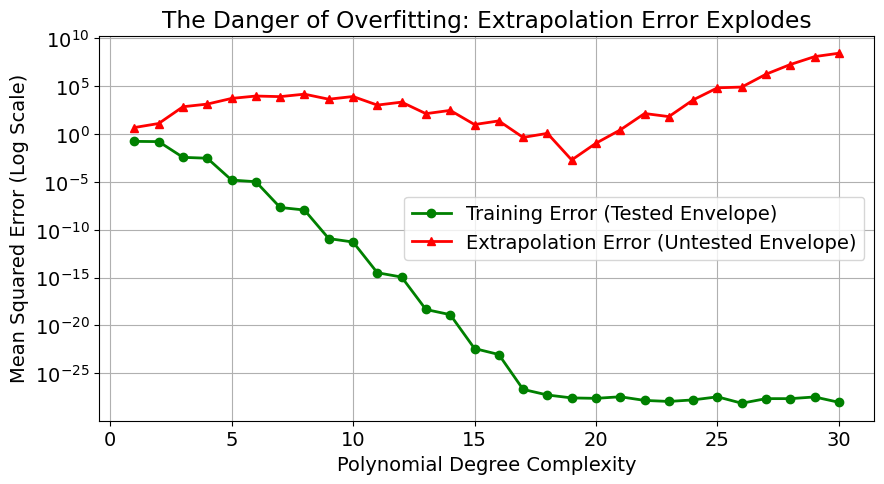

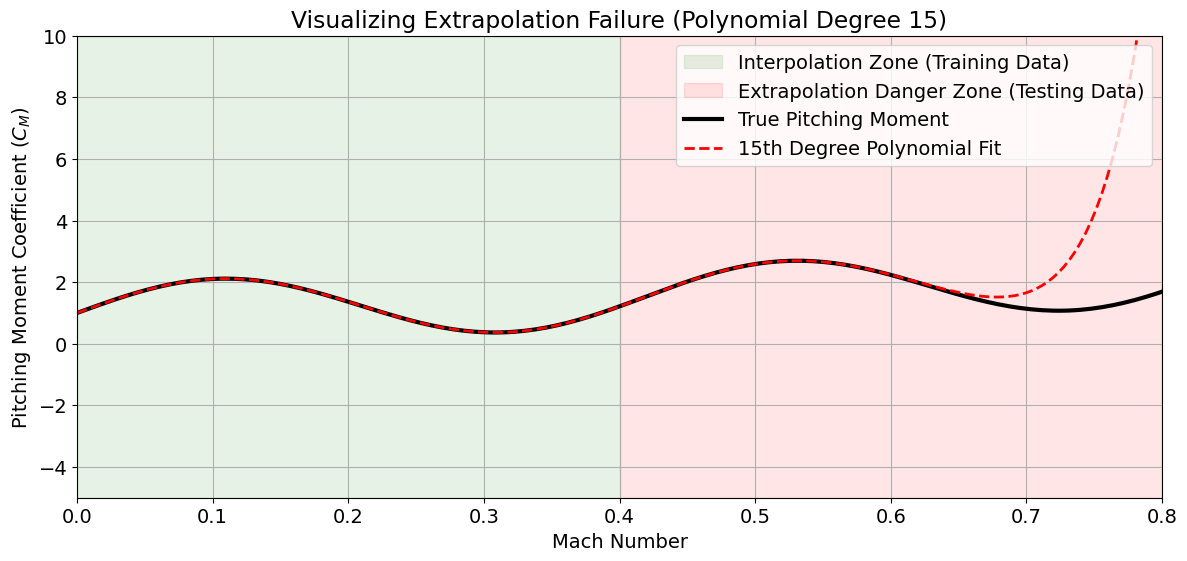

In [31]:
################################################################################
# Visualization 1: Error vs Polynomial Complexity
################################################################################
plt.figure()

degrees = np.arange(1, max_degree + 1)
plt.plot(degrees, mse_train, 'g-o', linewidth=2, label='Training Error (Tested Envelope)')
plt.plot(degrees, mse_test, 'r-^', linewidth=2, label='Extrapolation Error (Untested Envelope)')

# The extrapolation error explodes so massively we MUST use a log scale to see anything
plt.yscale('log')
plt.xlabel('Polynomial Degree Complexity')
plt.ylabel('Mean Squared Error (Log Scale)')
plt.title('The Danger of Overfitting: Extrapolation Error Explodes')
plt.legend()
plt.show()

################################################################################
# Visualization 2: What does Extrapolation Failure look like?
################################################################################
# Let's plot the actual curves for a 15th degree polynomial to see the failure visually.
problematic_degree = 15
problematic_coeffs = np.polyfit(mach_train, C_M_train, problematic_degree)
C_M_pred_full = np.polyval(problematic_coeffs, mach_array)

plt.figure(figsize=(14, 6))

# Highlight the distinct zones
plt.axvspan(0, 0.4, color='green', alpha=0.1, label='Interpolation Zone (Training Data)')
plt.axvspan(0.4, 0.8, color='red', alpha=0.1, label='Extrapolation Danger Zone (Testing Data)')

# Plot True physics vs the Model
plt.plot(mach_array, C_M_true, 'k-', linewidth=3, label='True Pitching Moment')
plt.plot(mach_array, C_M_pred_full, 'r--', linewidth=2, label=f'{problematic_degree}th Degree Polynomial Fit')

# Restrict Y-axis so the massive oscillation doesn't completely squash the true plot
plt.ylim(-5, 10)
plt.xlim(0, 0.8)

plt.xlabel('Mach Number')
plt.ylabel('Pitching Moment Coefficient ($C_M$)')
plt.title(f'Visualizing Extrapolation Failure (Polynomial Degree {problematic_degree})')
plt.legend(loc='upper right')
plt.show()

### Challenge Problem: Gaussian Process Regression (GPR)
Polynomials fail catastrophically at extrapolation. In machine learning for aerospace, **Gaussian Process Regression (GPR)** is preferred because it not only predicts values, but also provides **uncertainty bounds**. Your challenge: Use `GaussianProcessRegressor` from Scikit-Learn to fit the training data. Then, predict across the full `mach_array` and plot the 95% confidence interval. You will see GPR's uncertainty perfectly 'blow up' in the extrapolation zone, warning the engineer!

In [32]:
# YOUR CODE HERE
# 1. Import GaussianProcessRegressor and RBF kernel
# 2. Fit the model to mach_train and C_M_train (reshaped appropriately)
# 3. Predict C_M and the standard deviation (return_std=True) for the full mach_array
# 4. Plot the mean prediction and fill_between the +/- 1.96 standard deviations
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
# ...

<details>
<summary><b>Click to Reveal Solution</b></summary>

```python
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel

# 1. Setup GPR with an RBF (Radial Basis Function) Kernel
kernel = ConstantKernel(1.0) * RBF(length_scale=0.1)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, alpha=1e-2)

# 2. Fit strictly on the training zone
X_train = mach_train.reshape(-1, 1)
gpr.fit(X_train, C_M_train)

# 3. Predict across everything, asking for the standard deviation (uncertainty)
X_full = mach_array.reshape(-1, 1)
y_pred, y_std = gpr.predict(X_full, return_std=True)

# 4. Plot
plt.figure(figsize=(14, 6))
plt.axvspan(0, 0.4, color='green', alpha=0.1, label='Interpolation Zone')
plt.axvspan(0.4, 0.8, color='red', alpha=0.1, label='Extrapolation Danger Zone')

plt.plot(mach_array, C_M_true, 'k-', linewidth=3, label='True Pitching Moment')
plt.plot(mach_array, y_pred, 'b--', linewidth=2, label='GPR Mean Prediction')

# 95% Confidence Interval (1.96 * StdDev)
plt.fill_between(mach_array, y_pred - 1.96*y_std, y_pred + 1.96*y_std,
                 alpha=0.3, color='blue', label='95% Confidence Interval')

plt.ylim(-5, 10)
plt.xlim(0, 0.8)
plt.xlabel('Mach Number')
plt.ylabel('Pitching Moment')
plt.title('GPR Extrapolation: Notice how Uncertainty (Blue Shaded Area) explodes in the Danger Zone!')
plt.legend(loc='upper right')
plt.show()
```
</details>